In [1]:
import os
import mne
import numpy as np
from sklearn.utils import shuffle
import argparse

In [4]:
parser = argparse.ArgumentParser()
parser.add_argument('--sub', default=1, type=int)
parser.add_argument('--n_ses', default=4, type=int)
parser.add_argument('--sfreq', default=250, type=int)
parser.add_argument('--mvnn_dim', default='epochs', type=str)
parser.add_argument('--project_dir', default= r'D:\reproduction\BCI\EEG_Decoder\data', type=str)
args, unknown = parser.parse_known_args()

In [3]:
seed = 20200220

In [4]:

def epoching(args, data_part, seed):
	"""This function first converts the EEG data to MNE raw format, and
	performs channel selection, epoching, baseline correction and frequency
	downsampling. Then, it sorts the EEG data of each session according to the
	image conditions.

	Parameters
	----------
	args : Namespace
		Input arguments.
	data_part : str
		'test' or 'training' data partitions.
	seed : int
		Random seed.

	Returns
	-------
	epoched_data : list of float
		Epoched EEG data.
	img_conditions : list of int
		Unique image conditions of the epoched and sorted EEG data.
	ch_names : list of str
		EEG channel names.
	times : float
		EEG time points.

	"""


	chan_order = ['Fp1', 'Fp2', 'AF7', 'AF3', 'AFz', 'AF4', 'AF8', 'F7', 'F5', 'F3',
				  'F1', 'F2', 'F4', 'F6', 'F8', 'FT9', 'FT7', 'FC5', 'FC3', 'FC1', 
				  'FCz', 'FC2', 'FC4', 'FC6', 'FT8', 'FT10', 'T7', 'C5', 'C3', 'C1',
				  'Cz', 'C2', 'C4', 'C6', 'T8', 'TP9', 'TP7', 'CP5', 'CP3', 'CP1', 
				  'CPz', 'CP2', 'CP4', 'CP6', 'TP8', 'TP10', 'P7', 'P5', 'P3', 'P1',
				  'Pz', 'P2', 'P4', 'P6', 'P8', 'PO7', 'PO3', 'POz', 'PO4', 'PO8',
				  'O1', 'Oz', 'O2']

	### Loop across data collection sessions ###
	epoched_data = []
	img_conditions = []
	for s in range(args.n_ses):

		### Load the EEG data and convert it to MNE raw format ###
		eeg_dir = os.path.join("raw",  "sub-01",  "sub-01",  f"ses-{s+1:02}",  "raw_eeg_training.npy")
		eeg_data = np.load(os.path.join(args.project_dir, eeg_dir),
			allow_pickle=True).item()
		ch_names = eeg_data['ch_names']
		sfreq = eeg_data['sfreq']
		ch_types = eeg_data['ch_types']
		eeg_data = eeg_data['raw_eeg_data'].astype(np.float32)
		# Convert to MNE raw format
		info = mne.create_info(ch_names, sfreq, ch_types)
		raw = mne.io.RawArray(eeg_data, info)
		del eeg_data

		### Get events, drop unused channels and reject target trials ###
		events = mne.find_events(raw, stim_channel='stim')
		# # Select only occipital (O) and posterior (P) channels
		# chan_idx = np.asarray(mne.pick_channels_regexp(raw.info['ch_names'],
		# 	'^O *|^P *'))
		# new_chans = [raw.info['ch_names'][c] for c in chan_idx]
		# raw.pick_channels(new_chans)
		# * chose all channels
		raw.pick_channels(chan_order, ordered=True)
		# Reject the target trials (event 99999)
		idx_target = np.where(events[:,2] == 99999)[0]
		events = np.delete(events, idx_target, 0)
		### Epoching, baseline correction and resampling ###
		# * [0, 1.0]
		epochs = mne.Epochs(raw, events, tmin=-.2, tmax=1.0, baseline=(None,0),
			preload=True)
		# epochs = mne.Epochs(raw, events, tmin=-.2, tmax=.8, baseline=(None,0),
		# 	preload=True)
		del raw
		# Resampling
		if args.sfreq < 1000:
			epochs.resample(args.sfreq)
		ch_names = epochs.info['ch_names']
		times = epochs.times

		### Sort the data ###
		data = epochs.get_data()
		events = epochs.events[:,2]
		img_cond = np.unique(events)
		del epochs
		# Select only a maximum number of EEG repetitions
		if data_part == 'test':
			max_rep = 20
		else:
			max_rep = 2
		# Sorted data matrix of shape:
		# Image conditions × EEG repetitions × EEG channels × EEG time points
		sorted_data = np.zeros((len(img_cond),max_rep,data.shape[1],
			data.shape[2]))
		for i in range(len(img_cond)):
			# Find the indices of the selected image condition
			idx = np.where(events == img_cond[i])[0]
			# Randomly select only the max number of EEG repetitions
			idx = shuffle(idx, random_state=seed, n_samples=max_rep)
			sorted_data[i] = data[idx]
		del data
		epoched_data.append(sorted_data[:, :, :, 50:])
		img_conditions.append(img_cond)
		del sorted_data

	### Output ###
	return epoched_data, img_conditions, ch_names, times

In [5]:
epoched_train, img_conditions_train, _, _ = epoching(args, 'training', seed)
print("epoched_train",epoched_train)
print("img_conditions_train",img_conditions_train)

Creating RawArray with float64 data, n_channels=64, n_times=5450560
    Range : 0 ... 5450559 =      0.000 ...  5450.559 secs
Ready.
16800 events found on stim channel stim
Event IDs: [    1     2     3 ... 16529 16530 99999]
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Not setting metadata
16710 matching events found
Setting baseline interval to [-0.2, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 16710 events and 1201 original time points ...
0 bad epochs dropped
Creating RawArray with float64 data, n_channels=64, n_times=5302300
    Range : 0 ... 5302299 =      0.000 ...  5302.299 secs
Ready.
16800 events found on stim channel stim
Event IDs: [   11    12    13 ... 16539 16540 99999]
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Not setting metadata
16710 matching events found
Setting baseline interval to [-0.2, 0.0] s
Applying baseline correction (m

In [6]:
def epoching(args, data_part, seed):
	"""This function first converts the EEG data to MNE raw format, and
	performs channel selection, epoching, baseline correction and frequency
	downsampling. Then, it sorts the EEG data of each session according to the
	image conditions.

	Parameters
	----------
	args : Namespace
		Input arguments.
	data_part : str
		'test' or 'training' data partitions.
	seed : int
		Random seed.

	Returns
	-------
	epoched_data : list of float
		Epoched EEG data.
	img_conditions : list of int
		Unique image conditions of the epoched and sorted EEG data.
	ch_names : list of str
		EEG channel names.
	times : float
		EEG time points.

	"""


	chan_order = ['Fp1', 'Fp2', 'AF7', 'AF3', 'AFz', 'AF4', 'AF8', 'F7', 'F5', 'F3',
				  'F1', 'F2', 'F4', 'F6', 'F8', 'FT9', 'FT7', 'FC5', 'FC3', 'FC1', 
				  'FCz', 'FC2', 'FC4', 'FC6', 'FT8', 'FT10', 'T7', 'C5', 'C3', 'C1',
				  'Cz', 'C2', 'C4', 'C6', 'T8', 'TP9', 'TP7', 'CP5', 'CP3', 'CP1', 
				  'CPz', 'CP2', 'CP4', 'CP6', 'TP8', 'TP10', 'P7', 'P5', 'P3', 'P1',
				  'Pz', 'P2', 'P4', 'P6', 'P8', 'PO7', 'PO3', 'POz', 'PO4', 'PO8',
				  'O1', 'Oz', 'O2']

	### Loop across data collection sessions ###
	epoched_data = []
	img_conditions = []
	for s in range(args.n_ses):

		### Load the EEG data and convert it to MNE raw format ###
		eeg_dir = os.path.join("raw",  "sub-01",  "sub-01",  f"ses-{s+1:02}",  "raw_eeg_test.npy")
		eeg_data = np.load(os.path.join(args.project_dir, eeg_dir),
			allow_pickle=True).item()
		ch_names = eeg_data['ch_names']
		sfreq = eeg_data['sfreq']
		ch_types = eeg_data['ch_types']
		eeg_data = eeg_data['raw_eeg_data'].astype(np.float32)
		# Convert to MNE raw format
		info = mne.create_info(ch_names, sfreq, ch_types)
		raw = mne.io.RawArray(eeg_data, info)
		del eeg_data

		### Get events, drop unused channels and reject target trials ###
		events = mne.find_events(raw, stim_channel='stim')
		# # Select only occipital (O) and posterior (P) channels
		# chan_idx = np.asarray(mne.pick_channels_regexp(raw.info['ch_names'],
		# 	'^O *|^P *'))
		# new_chans = [raw.info['ch_names'][c] for c in chan_idx]
		# raw.pick_channels(new_chans)
		# * chose all channels
		raw.pick_channels(chan_order, ordered=True)
		# Reject the target trials (event 99999)
		idx_target = np.where(events[:,2] == 99999)[0]
		events = np.delete(events, idx_target, 0)
		### Epoching, baseline correction and resampling ###
		# * [0, 1.0]
		epochs = mne.Epochs(raw, events, tmin=-.2, tmax=1.0, baseline=(None,0),
			preload=True)
		# epochs = mne.Epochs(raw, events, tmin=-.2, tmax=.8, baseline=(None,0),
		# 	preload=True)
		del raw
		# Resampling
		if args.sfreq < 1000:
			epochs.resample(args.sfreq)
		ch_names = epochs.info['ch_names']
		times = epochs.times

		### Sort the data ###
		data = epochs.get_data()
		events = epochs.events[:,2]
		img_cond = np.unique(events)
		del epochs
		# Select only a maximum number of EEG repetitions
		if data_part == 'test':
			max_rep = 20
		else:
			max_rep = 2
		# Sorted data matrix of shape:
		# Image conditions × EEG repetitions × EEG channels × EEG time points
		sorted_data = np.zeros((len(img_cond),max_rep,data.shape[1],
			data.shape[2]))
		for i in range(len(img_cond)):
			# Find the indices of the selected image condition
			idx = np.where(events == img_cond[i])[0]
			# Randomly select only the max number of EEG repetitions
			idx = shuffle(idx, random_state=seed, n_samples=max_rep)
			sorted_data[i] = data[idx]
		del data
		epoched_data.append(sorted_data[:, :, :, 50:])
		img_conditions.append(img_cond)
		del sorted_data

	### Output ###
	return epoched_data, img_conditions, ch_names, times

In [7]:
epoched_test, img_conditions_test, ch_names, times = epoching(args, 'test', seed)
print("epoched_test",epoched_test)
print("img_conditions_test",img_conditions_test)

Creating RawArray with float64 data, n_channels=64, n_times=1355160
    Range : 0 ... 1355159 =      0.000 ...  1355.159 secs
Ready.
4080 events found on stim channel stim
Event IDs: [    1     2     3     4     5     6     7     8     9    10    11    12
    13    14    15    16    17    18    19    20    21    22    23    24
    25    26    27    28    29    30    31    32    33    34    35    36
    37    38    39    40    41    42    43    44    45    46    47    48
    49    50    51    52    53    54    55    56    57    58    59    60
    61    62    63    64    65    66    67    68    69    70    71    72
    73    74    75    76    77    78    79    80    81    82    83    84
    85    86    87    88    89    90    91    92    93    94    95    96
    97    98    99   100   101   102   103   104   105   106   107   108
   109   110   111   112   113   114   115   116   117   118   119   120
   121   122   123   124   125   126   127   128   129   130   131   132
   133   134  

In [8]:
type(epoched_train)

list

In [10]:
epoched_train[1].shape

(8270, 2, 63, 250)

In [14]:
img_conditions_train[0][270]

501

In [8]:
def mvnn(args, epoched_test, epoched_train):

	import numpy as np
	from tqdm import tqdm
	from sklearn.discriminant_analysis import _cov
	import scipy

	### Loop across data collection sessions ###
	whitened_test = []
	whitened_train = []
	for s in range(args.n_ses):
		session_data = [epoched_test[s], epoched_train[s]]

		### Compute the covariance matrices ###
		# Data partitions covariance matrix of shape:
		# Data partitions × EEG channels × EEG channels
		sigma_part = np.empty((len(session_data),session_data[0].shape[2],
			session_data[0].shape[2]))
		for p in range(sigma_part.shape[0]):
			# Image conditions covariance matrix of shape:
			# Image conditions × EEG channels × EEG channels
			sigma_cond = np.empty((session_data[p].shape[0],
				session_data[0].shape[2],session_data[0].shape[2]))
			for i in tqdm(range(session_data[p].shape[0])):
				cond_data = session_data[p][i]
				# Compute covariace matrices at each time point, and then
				# average across time points
				if args.mvnn_dim == "time":
					sigma_cond[i] = np.mean([_cov(cond_data[:,:,t],
						shrinkage='auto') for t in range(cond_data.shape[2])],
						axis=0)
				# Compute covariace matrices at each epoch (EEG repetition),
				# and then average across epochs/repetitions
				elif args.mvnn_dim == "epochs":
					# sigma_cond[i]里存着20个rep的协方差矩阵
					sigma_cond[i] = np.mean([_cov(np.transpose(cond_data[e]),
						shrinkage='auto') for e in range(cond_data.shape[0])],
						axis=0)
			# Average the covariance matrices across image conditions
			# sigma_cond共有200个协方差矩阵
			sigma_part[p] = sigma_cond.mean(axis=0)
		# # Average the covariance matrices across image partitions
		# sigma_tot = sigma_part.mean(axis=0)
		# ? It seems not fair to use test data for mvnn, so we change to just use training data
		sigma_tot = sigma_part[1]
		# Compute the inverse of the covariance matrix
		sigma_inv = scipy.linalg.fractional_matrix_power(sigma_tot, -0.5)

		### Whiten the data ###
		whitened_test.append(np.reshape((np.reshape(session_data[0], (-1,
			session_data[0].shape[2],session_data[0].shape[3])).swapaxes(1, 2)
			@ sigma_inv).swapaxes(1, 2), session_data[0].shape))
		whitened_train.append(np.reshape((np.reshape(session_data[1], (-1,
			session_data[1].shape[2],session_data[1].shape[3])).swapaxes(1, 2)
				@ sigma_inv).swapaxes(1, 2), session_data[1].shape))

	### Output ###
	return whitened_test, whitened_train

In [21]:
def save_prepr(args, whitened_test, whitened_train, img_conditions_train,
	ch_names, times, seed):
	"""Merge the EEG data of all sessions together, shuffle the EEG repetitions
	across sessions and reshaping the data to the format:
	Image conditions × EGG repetitions × EEG channels × EEG time points.
	Then, the data of both test and training EEG partitions is saved.

	Parameters
	----------
	args : Namespace
		Input arguments.
	whitened_test : list of float
		Whitened test EEG data.
	whitened_train : list of float
		Whitened training EEG data.
	img_conditions_train : list of int
		Unique image conditions of the epoched and sorted train EEG data.
	ch_names : list of str
		EEG channel names.
	times : float
		EEG time points.
	seed : int
		Random seed.

	"""

	import numpy as np
	from sklearn.utils import shuffle
	import os
	import pickle

	### Merge and save the test data ###
	for s in range(args.n_ses):
		if s == 0:
			merged_test = whitened_test[s]
		else:
			merged_test = np.append(merged_test, whitened_test[s], 1)
	del whitened_test
	# Shuffle the repetitions of different sessions
	idx = shuffle(np.arange(0, merged_test.shape[1]), random_state=seed)
	# merged_test[:, idx] 表示对 merged_test 的第 2 维（大小为 20）按照 idx 的顺序重新排列，而其他维度 (200,63,300) 不受影响
	merged_test = merged_test[:,idx]
	# Insert the data into a dictionary
	test_dict = {
		'preprocessed_eeg_data': merged_test,
		'ch_names': ch_names,
		'times': times
	}
	del merged_test
	# Saving directories
	save_dir = os.path.join(args.project_dir,
		"retry", "Preprocessed_data_250Hz", "sub-"+format(args.sub,'01'))
	file_name_test = "preprocessed_eeg_test.npy"
	file_name_train = "preprocessed_eeg_training.npy"
	# Create the directory if not existing and save the data
	if os.path.isdir(save_dir) == False:
		os.makedirs(save_dir)
	# np.save(os.path.join(save_dir, file_name_test), test_dict)
	save_pic = open(os.path.join(save_dir, file_name_test), 'wb')
	pickle.dump(test_dict, save_pic, protocol=4)
	save_pic.close()
	del test_dict

	### Merge and save the training data ###
	for s in range(args.n_ses):
		if s == 0:
			white_data = whitened_train[s]
			img_cond = img_conditions_train[s]
		else:
			white_data = np.append(white_data, whitened_train[s], 0)
			img_cond = np.append(img_cond, img_conditions_train[s], 0)
	del whitened_train, img_conditions_train
	# Data matrix of shape:
	# Image conditions × EGG repetitions × EEG channels × EEG time points
	merged_train = np.zeros((len(np.unique(img_cond)), white_data.shape[1]*2,
		white_data.shape[2],white_data.shape[3]), dtype=np.float32)
	for i in range(len(np.unique(img_cond))):
		# Find the indices of the selected category
		idx = np.where(img_cond == i+1)[0]
		for r in range(len(idx)):
			if r == 0:
				ordered_data = white_data[idx[r]]
			else:
				ordered_data = np.append(ordered_data, white_data[idx[r]], 0)
		merged_train[i] = ordered_data
	# Shuffle the repetitions of different sessions
	idx = shuffle(np.arange(0, merged_train.shape[1]), random_state=seed)
	merged_train = merged_train[:,idx]
	# Insert the data into a dictionary
	train_dict = {
		'preprocessed_eeg_data': merged_train,
		'ch_names': ch_names,
		'times': times
	}
	del merged_train
	# Create the directory if not existing and save the data
	if os.path.isdir(save_dir) == False:
		os.makedirs(save_dir)
	# np.save(os.path.join(save_dir, file_name_train),
	# 	train_dict)
	save_pic = open(os.path.join(save_dir, file_name_train), 'wb')
	pickle.dump(train_dict, save_pic, protocol=4)
	save_pic.close()
	del train_dict

In [10]:
whitened_test, whitened_train = mvnn(args, epoched_test, epoched_train)

100%|█████████████████████████████████████████████████████████████████████████████| 8270/8270 [00:31<00:00, 261.57it/s]


In [11]:
a = np.array([[1, 2], 
              [3, 4]])

result = np.where(a > 2)
print(result)

(array([1, 1], dtype=int64), array([0, 1], dtype=int64))


In [13]:
del epoched_test, epoched_train

In [18]:
whitened_test = [x.astype(np.float32) for x in whitened_test]

In [19]:
whitened_train = [x.astype(np.float32) for x in whitened_train]

In [24]:
save_prepr(args, whitened_test, whitened_train, img_conditions_train, ch_names,
	times, seed)

MemoryError: Unable to allocate 2.91 GiB for an array with shape (24810, 2, 63, 250) and data type float32

In [15]:
type(whitened_test)

list

In [17]:
whitened_test[1].shape

(200, 20, 63, 250)

In [6]:
file_path = os.path.join(args.project_dir,
		"retry", "Preprocessed_data_250Hz", "sub-"+format(args.sub,'01'), "preprocessed_eeg_test.npy")
data = np.load(file_path, allow_pickle=True)

In [7]:
type(data)

dict

In [9]:
data['preprocessed_eeg_data'].shape

(200, 80, 63, 250)

In [10]:
chan_order = ['Fp1', 'Fp2', 'AF7', 'AF3', 'AFz', 'AF4', 'AF8', 'F7', 'F5', 'F3',
				  'F1', 'F2', 'F4', 'F6', 'F8', 'FT9', 'FT7', 'FC5', 'FC3', 'FC1', 
				  'FCz', 'FC2', 'FC4', 'FC6', 'FT8', 'FT10', 'T7', 'C5', 'C3', 'C1',
				  'Cz', 'C2', 'C4', 'C6', 'T8', 'TP9', 'TP7', 'CP5', 'CP3', 'CP1', 
				  'CPz', 'CP2', 'CP4', 'CP6', 'TP8', 'TP10', 'P7', 'P5', 'P3', 'P1',
				  'Pz', 'P2', 'P4', 'P6', 'P8', 'PO7', 'PO3', 'POz', 'PO4', 'PO8',
				  'O1', 'Oz', 'O2']

### Loop across data collection sessions ###
epoched_data = []
img_conditions = []
##for s in range(args.n_ses):

### Load the EEG data and convert it to MNE raw format ###
s = 0
eeg_dir = os.path.join("raw",  "sub-01",  "sub-01",  f"ses-{s+1:02}",  "raw_eeg_training.npy")
eeg_data = np.load(os.path.join(args.project_dir, eeg_dir),
    allow_pickle=True).item()
ch_names = eeg_data['ch_names']
sfreq = eeg_data['sfreq']
ch_types = eeg_data['ch_types']
eeg_data = eeg_data['raw_eeg_data'].astype(np.float32)
# Convert to MNE raw format
info = mne.create_info(ch_names, sfreq, ch_types)
raw = mne.io.RawArray(eeg_data, info)
del eeg_data

### Get events, drop unused channels and reject target trials ###
events = mne.find_events(raw, stim_channel='stim')
# # Select only occipital (O) and posterior (P) channels
# chan_idx = np.asarray(mne.pick_channels_regexp(raw.info['ch_names'],
# 	'^O *|^P *'))
# new_chans = [raw.info['ch_names'][c] for c in chan_idx]
# raw.pick_channels(new_chans)
# * chose all channels
raw.pick_channels(chan_order, ordered=True)
# Reject the target trials (event 99999)
idx_target = np.where(events[:,2] == 99999)[0]
events = np.delete(events, idx_target, 0)
### Epoching, baseline correction and resampling ###
# * [0, 1.0]
epochs = mne.Epochs(raw, events, tmin=-.2, tmax=1.0, baseline=(None,0),
    preload=True)
# epochs = mne.Epochs(raw, events, tmin=-.2, tmax=.8, baseline=(None,0),
# 	preload=True)
del raw
# Resampling
if args.sfreq < 1000:
    epochs.resample(args.sfreq)
ch_names = epochs.info['ch_names']
times = epochs.times

### Sort the data ###
data = epochs.get_data()
events = epochs.events[:,2]
img_cond = np.unique(events)

Creating RawArray with float64 data, n_channels=64, n_times=5450560
    Range : 0 ... 5450559 =      0.000 ...  5450.559 secs
Ready.
16800 events found on stim channel stim
Event IDs: [    1     2     3 ... 16529 16530 99999]
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Not setting metadata
16710 matching events found
Setting baseline interval to [-0.2, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 16710 events and 1201 original time points ...
0 bad epochs dropped


In [11]:
type(data)

numpy.ndarray

In [12]:
data.shape

(16710, 63, 300)

In [16]:
import torch.fft as fft
import torch

In [17]:
file_path = os.path.join(args.project_dir,
		"retry", "Preprocessed_data_250Hz", "sub-"+format(args.sub,'01'), "preprocessed_eeg_test.npy")
data = np.load(file_path, allow_pickle=True)
preprocessed_eeg_data = torch.from_numpy(data['preprocessed_eeg_data']).float().detach()
fft_x = fft.rfft(preprocessed_eeg_data, dim=-1)

In [19]:
fft_x.shape

torch.Size([200, 80, 63, 126])

In [20]:
import numpy
import matplotlib.pyplot as plt

In [22]:
def stft(signal,window_size, overlap):
    step = window_size - overlap
    window = np.hanning(window_size)
    segments = np.array([signal[i:i+window_size] * window for i in range(0, len(signal) - window_size, step)])
    return np.fft.fft(segments, dim=-1)

In [45]:
signal = preprocessed_eeg_data[1]

In [46]:
signal.shape

torch.Size([80, 63, 250])

In [26]:
Fs = 250
T = 1/Fs
t = np.arange(0, 1, T)
testsignal = 0.5 * np.sin(2*np.pi *50 *t) + 0.5 * np.sin(2 * np.pi *120 *t)
testsignal.shape

(250,)

In [ ]:
window_size = 32
overlap = 16

frequencies = stft(signal,window,overlap)
freqs = np.fft.fftfreq(window_size, 1/Fs)

plt.figure(figsize=(10,6))
plt.imshow(np.abs(frequencies))

In [39]:
import torch
import torch.nn as nn

# 假设数据形状为 [batch_size, channels, times]
batch_size, channels, times = 80, 63, 250
data = torch.randn(batch_size, channels, times)

# STFT 参数
window_size = 32
hop_size = 16
window = torch.hann_window(window_size)

# STFT 计算
stft_result = []
for b in range(batch_size):
    channel_stft = []
    for c in range(channels):
        stft = torch.stft(
            signal[b, c],
            n_fft=window_size,
            hop_length=hop_size,
            win_length=window_size,
            window=window,
            return_complex=True
        )
        magnitude = stft.abs()  # 振幅谱
        phase_sin = torch.sin(stft.angle())  # 相位的正弦
        phase_cos = torch.cos(stft.angle())  # 相位的余弦

        # 组合特征
        combined = torch.stack([magnitude, phase_sin, phase_cos], dim=0)  # 特征通道
        channel_stft.append(combined)

    stft_result.append(torch.stack(channel_stft))

# 最终特征形状为 [batch_size, channels, 3, freq_bins, time_frames]
stft_features = torch.stack(stft_result)

In [40]:
stft_features.shape

torch.Size([80, 63, 3, 17, 16])

In [47]:
import torch
import torch.fft
import matplotlib.pyplot as plt

def process_stft(data, sampling_rate, window_size, hop_size, window_fn=torch.hann_window):
    """
    对输入数据进行短时傅里叶变换 (STFT) 并返回时频特征。
    
    Args:
        data (torch.Tensor): 输入数据，形状为 [batch_size, channels, times]。
        sampling_rate (float): 数据的采样率 (Hz)。
        window_size (int): 窗函数的长度 (样本点数)。
        hop_size (int): 帧移 (每次移动的样本点数)。
        window_fn (callable): 窗函数生成器，默认使用汉宁窗。
        
    Returns:
        stft_magnitude (torch.Tensor): 幅值谱，形状为 [batch_size, channels, freq_bins, time_frames]。
        freqs (torch.Tensor): 频率轴，形状为 [freq_bins]。
        times (torch.Tensor): 时间轴，形状为 [time_frames]。
    """
    batch_size, channels, times = data.shape
    window = window_fn(window_size).to(data.device)  # 生成窗函数
    stft_result = []

    for b in range(batch_size):
        batch_stft = []
        for c in range(channels):
            # 对每个通道计算 STFT
            stft = torch.stft(
                signal[b, c],
                n_fft=window_size,
                hop_length=hop_size,
                win_length=window_size,
                window=window,
                return_complex=True
            )
            batch_stft.append(stft.abs())  # 取幅值谱
        stft_result.append(torch.stack(batch_stft))

    stft_magnitude = torch.stack(stft_result)  # 合并批次

    # 计算频率和时间轴
    freq_bins = window_size // 2 + 1
    freqs = torch.linspace(0, sampling_rate / 2, freq_bins)  # 频率轴
    time_frames = (times - window_size) // hop_size + 1
    times = torch.linspace(0, (time_frames - 1) * hop_size / sampling_rate, time_frames)  # 时间轴

    return stft_magnitude, freqs, times

In [48]:
def plot_spectrogram(stft_magnitude, freqs, times, channel_idx=0, batch_idx=0):
    """
    绘制指定批次和通道的频谱图。
    
    Args:
        stft_magnitude (torch.Tensor): 幅值谱，形状为 [batch_size, channels, freq_bins, time_frames]。
        freqs (torch.Tensor): 频率轴，形状为 [freq_bins]。
        times (torch.Tensor): 时间轴，形状为 [time_frames]。
        channel_idx (int): 要绘制的通道索引。
        batch_idx (int): 要绘制的批次索引。
    """
    # 提取指定批次和通道的数据
    spectrogram = stft_magnitude[batch_idx, channel_idx].cpu().numpy()

    plt.figure(figsize=(10, 6))
    plt.pcolormesh(times, freqs, spectrogram, shading='gouraud', cmap='viridis')
    plt.colorbar(label="Magnitude")
    plt.title(f"Spectrogram (Batch {batch_idx}, Channel {channel_idx})")
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.tight_layout()
    plt.show()

TypeError: Dimensions of C (17, 16) are incompatible with X (14) and/or Y (17); see help(pcolormesh)

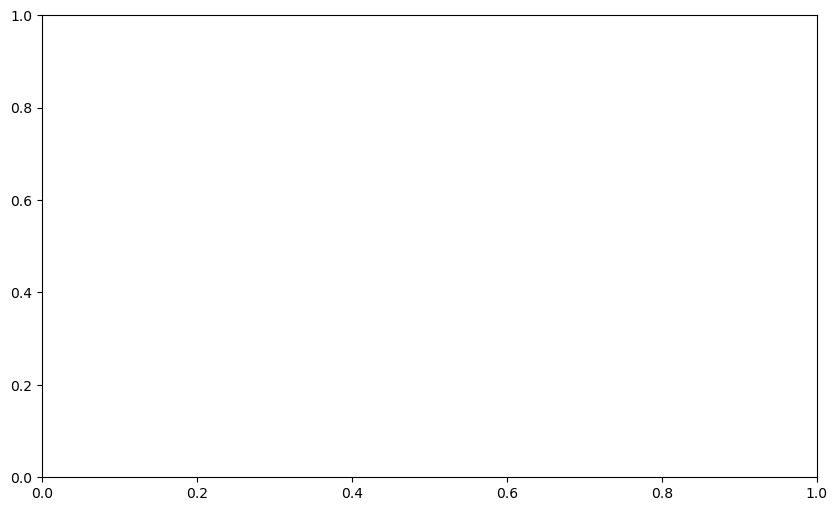

In [49]:
# 假设数据形状为 [batch_size, channels, times]
batch_size, channels, times = 80, 63, 250

# STFT 参数
window_size = 32
hop_size = 16
window = torch.hann_window(window_size)
sampling_rate = 8
stft_magnitude, freqs, times = process_stft(signal, sampling_rate, window_size, hop_size)

# 绘制频谱图
plot_spectrogram(stft_magnitude, freqs, times, channel_idx=0, batch_idx=0)

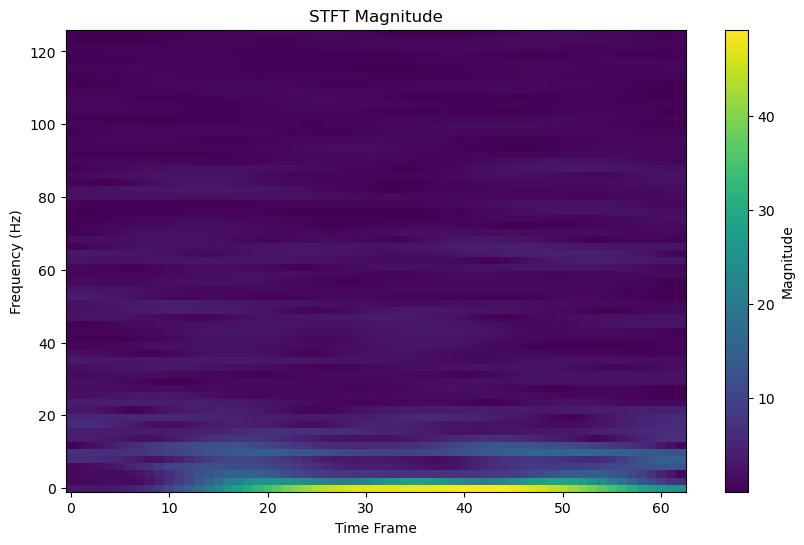

In [146]:
# 获取一个样本（例如 batch 0, channel 0）
sample_signal = signal[40, 53]

# STFT 参数
window_size = 128
hop_size = 4
sampling_rate = 250
window = torch.hann_window(window_size)
# 计算 STFT
stft_result = torch.stft(
    sample_signal,
    n_fft=window_size,
    hop_length=hop_size,
    win_length=window_size,
    window=window,
    return_complex=True
)

# 提取幅度谱
magnitude = stft_result.abs()
magnitude_positive_freq = magnitude[:window_size//2 + 1, :]

# 创建频率和时间轴
freqs = np.fft.fftfreq(window_size, d=1.0/sampling_rate)[:window_size//2+1]
freqs = np.abs(freqs)
times = np.arange(magnitude_positive_freq.shape[-1])

# 绘制时频图
plt.figure(figsize=(10, 6))
plt.pcolormesh(times, freqs, magnitude_positive_freq.numpy(), shading='auto')
plt.colorbar(label='Magnitude')
plt.xlabel('Time Frame')
plt.ylabel('Frequency (Hz)')
plt.title('STFT Magnitude')
plt.show()

In [145]:
stft_result = torch.stft(
    sample_signal,
    n_fft=window_size,
    hop_length=hop_size,
    win_length=window_size,
    window=window,
    return_complex=True
)
stft_result.is_complex()

True

In [64]:

# 获取一个样本（例如 batch 0, channel 0）
sample_signal = signal[0, 0]

# 计算 STFT
stft_result = torch.stft(
    sample_signal,
    n_fft=window_size,
    hop_length=hop_size,
    win_length=window_size,
    window=window,
    return_complex=True
)

# 检查 stft_result 的形状
print(f"STFT result shape: {stft_result.shape}")

# 提取幅度谱
magnitude = stft_result.abs()

# 仅保留正频率部分（即从 0 到 window_size//2）
# 假设 stft_result 是四维张量，形状为 [batch_size, channels, freq_bins, time_frames]
# 如果是二维张量 [freq_bins, time_frames]，我们只需要切取正频率部分
# 这里的切片适用于四维 stft_result
magnitude_positive_freq = magnitude[:, :, :window_size//2 + 1, :]

# 创建频率和时间轴
freqs = np.fft.fftfreq(window_size, d=1.0/sampling_rate)[:window_size//2 + 1]
times = np.arange(magnitude_positive_freq.shape[-1])

# 绘制时频图
plt.figure(figsize=(10, 6))
plt.pcolormesh(times, freqs, magnitude_positive_freq[0, 0, :, :].numpy(), shading='auto')  # 绘制第一个样本，第一个通道
plt.colorbar(label='Magnitude')
plt.xlabel('Time Frame')
plt.ylabel('Frequency (Hz)')
plt.title('STFT Magnitude (Positive Frequencies)')
plt.show()

STFT result shape: torch.Size([9, 251])


IndexError: too many indices for tensor of dimension 2

In [75]:
freqs

array([ 0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,  1.75, -2.  ])

In [3]:
a = np.zeros((2,5))
b = np.zeros((2,5))

In [6]:
c = []
c.append(a)
c.append(b)
np.shape(c)

(2, 2, 5)

In [1]:
import os
import json

# Load the configuration from the JSON file
config_path = "data_config.json"
with open(config_path, "r") as config_file:
    config = json.load(config_file)

# Access the paths from the config
data_path = config["data_path"]
img_directory_training = config["img_directory_training"]
img_directory_test = config["img_directory_test"]

In [2]:
directory = img_directory_training
os.listdir(directory)

['00001_aardvark',
 '00002_abacus',
 '00003_accordion',
 '00004_acorn',
 '00005_air_conditioner',
 '00006_air_mattress',
 '00007_air_pump',
 '00008_airbag',
 '00009_airboat',
 '00010_airplane',
 '00011_album',
 '00012_alligator',
 '00013_almond',
 '00014_aloe',
 '00015_alpaca',
 '00016_altar',
 '00017_aluminum_foil',
 '00018_amber',
 '00019_ambulance',
 '00020_amplifier',
 '00021_anchor',
 '00022_ankle',
 '00023_anklet',
 '00024_ant',
 '00025_anteater',
 '00026_antenna',
 '00027_anvil',
 '00028_appetizer',
 '00029_apple',
 '00030_apple_tree',
 '00031_applesauce',
 '00032_apron',
 '00033_aquarium',
 '00034_arch',
 '00035_arm',
 '00036_armor',
 '00037_arrow',
 '00038_artichoke',
 '00039_arugula',
 '00040_ashtray',
 '00041_asparagus',
 '00042_avocado',
 '00043_awning',
 '00044_axe',
 '00045_baby',
 '00046_backdrop',
 '00047_backgammon',
 '00048_backpack',
 '00049_bacon',
 '00050_badge',
 '00051_badger',
 '00052_bag',
 '00053_bagel',
 '00054_bagpipe',
 '00055_baklava',
 '00056_ball',
 '000

In [3]:
dirnames = [d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))]
dirnames

['00001_aardvark',
 '00002_abacus',
 '00003_accordion',
 '00004_acorn',
 '00005_air_conditioner',
 '00006_air_mattress',
 '00007_air_pump',
 '00008_airbag',
 '00009_airboat',
 '00010_airplane',
 '00011_album',
 '00012_alligator',
 '00013_almond',
 '00014_aloe',
 '00015_alpaca',
 '00016_altar',
 '00017_aluminum_foil',
 '00018_amber',
 '00019_ambulance',
 '00020_amplifier',
 '00021_anchor',
 '00022_ankle',
 '00023_anklet',
 '00024_ant',
 '00025_anteater',
 '00026_antenna',
 '00027_anvil',
 '00028_appetizer',
 '00029_apple',
 '00030_apple_tree',
 '00031_applesauce',
 '00032_apron',
 '00033_aquarium',
 '00034_arch',
 '00035_arm',
 '00036_armor',
 '00037_arrow',
 '00038_artichoke',
 '00039_arugula',
 '00040_ashtray',
 '00041_asparagus',
 '00042_avocado',
 '00043_awning',
 '00044_axe',
 '00045_baby',
 '00046_backdrop',
 '00047_backgammon',
 '00048_backpack',
 '00049_bacon',
 '00050_badge',
 '00051_badger',
 '00052_bag',
 '00053_bagel',
 '00054_bagpipe',
 '00055_baklava',
 '00056_ball',
 '000

In [4]:
for dir in dirnames:
    idx = dir.index('_')
    print(idx)

5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5


In [1]:
import json
import os
# Load the configuration from the JSON file
config_path = "data_config.json"
with open(config_path, "r") as config_file:
    config = json.load(config_file)

# Access the paths from the config
data_path = config["data_path"]
img_directory_training = config["img_directory_training"]
img_directory_test = config["img_directory_test"]

In [2]:
import numpy as np
import torch
file_name = 'preprocessed_eeg_test.npy'
subject = 'sub-08'
file_path = os.path.join(data_path, subject, file_name)
data = np.load(file_path, allow_pickle=True)
preprocessed_eeg_data = torch.from_numpy(data['preprocessed_eeg_data']).float().detach()
eeg_data = preprocessed_eeg_data[0: 1]
print(eeg_data.shape)
print(eeg_data.squeeze(0).shape)
eeg_data_class = torch.mean(eeg_data.squeeze(0), 0)
print(eeg_data_class.shape)

torch.Size([1, 80, 63, 100])
torch.Size([80, 63, 100])
torch.Size([63, 100])


In [45]:
labels = torch.full((10,), 0, dtype = torch.long).detach()
labels.shape
label_list = []
label_list.append(labels)
print(label_list)
labels = torch.full((10,), 1, dtype = torch.long).detach()
label_list.append(labels)
print(label_list)
label_tensor = torch.cat(label_list, dim=0).view(-1,*label_tensor[0].shape)
print(label_tensor.shape)

[tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])]
[tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])]
torch.Size([20])


In [54]:
data_path = config["data_path"]

def load_eeg_data(subject, train):
            if train:
                file_name = 'preprocessed_eeg_training.npy'
                n_classes = 1654
                samples_per_class = 10
                repeat_times = 4
            else:
                file_name = 'preprocessed_eeg_test.npy'
                n_classes = 200
                samples_per_class = 1
                repeat_times = 80
                
            file_path = os.path.join(data_path, subject, file_name)
            data = np.load(file_path, allow_pickle=True)
                    
            preprocessed_eeg_data = torch.from_numpy(data['preprocessed_eeg_data']).float().detach()
            times = torch.from_numpy(data['times']).detach()[20:]
            ch_names = data['ch_names']
            
            data_list = []
            label_list = []
            for i in range(n_classes):
                start_index = i * samples_per_class
                eeg_data = preprocessed_eeg_data[start_index: start_index + samples_per_class]
                labels = torch.full((samples_per_class * repeat_times,), i, dtype = torch.long).detach()
                # eeg_data = torch.mean(eeg_data, 1)
                data_list.append(eeg_data)
                label_list.append(labels)
            return data_list, label_list, times

data_list_train, label_list_train, times = load_eeg_data('sub-08', True)
data_list_train[0].shape

torch.Size([10, 4, 63, 100])

In [47]:
data_tensor = torch.cat(data_list_train, dim=0).view(-1, *data_list_train[0].shape[2:])
data_tensor.shape

torch.Size([66160, 63, 100])

In [48]:
print(len(label_list_train))
label_tensor_train = torch.cat(label_list_train, dim=0)
print(label_tensor_train.shape)

1654
torch.Size([66160])


In [49]:
data_list_test, label_list_test, times = load_eeg_data('sub-08', False)
data_list_test[0].shape

torch.Size([1, 80, 63, 100])

In [50]:
data_tensor_test = torch.cat(data_list_test, dim=0).view(-1, *data_list_train[0].shape[2:])
data_tensor_test.shape

torch.Size([16000, 63, 100])

In [51]:
label_tensor_train = torch.cat(label_list_test, dim=0)
print(label_tensor_train.shape)

torch.Size([16000])


In [ ]:
print(label_list_test.shape)
label_tensor_train = torch.cat(label_list_test, dim=0)
print(label_list_test.shape)

In [17]:
signal = data_list_test[0][0]
signal.shape

torch.Size([80, 63, 100])

In [55]:
times

tensor([0.0000, 0.0100, 0.0200, 0.0300, 0.0400, 0.0500, 0.0600, 0.0700, 0.0800,
        0.0900, 0.1000, 0.1100, 0.1200, 0.1300, 0.1400, 0.1500, 0.1600, 0.1700,
        0.1800, 0.1900, 0.2000, 0.2100, 0.2200, 0.2300, 0.2400, 0.2500, 0.2600,
        0.2700, 0.2800, 0.2900, 0.3000, 0.3100, 0.3200, 0.3300, 0.3400, 0.3500,
        0.3600, 0.3700, 0.3800, 0.3900, 0.4000, 0.4100, 0.4200, 0.4300, 0.4400,
        0.4500, 0.4600, 0.4700, 0.4800, 0.4900, 0.5000, 0.5100, 0.5200, 0.5300,
        0.5400, 0.5500, 0.5600, 0.5700, 0.5800, 0.5900, 0.6000, 0.6100, 0.6200,
        0.6300, 0.6400, 0.6500, 0.6600, 0.6700, 0.6800, 0.6900, 0.7000, 0.7100,
        0.7200, 0.7300, 0.7400, 0.7500, 0.7600, 0.7700, 0.7800, 0.7900, 0.8000,
        0.8100, 0.8200, 0.8300, 0.8400, 0.8500, 0.8600, 0.8700, 0.8800, 0.8900,
        0.9000, 0.9100, 0.9200, 0.9300, 0.9400, 0.9500, 0.9600, 0.9700, 0.9800,
        0.9900], dtype=torch.float64)

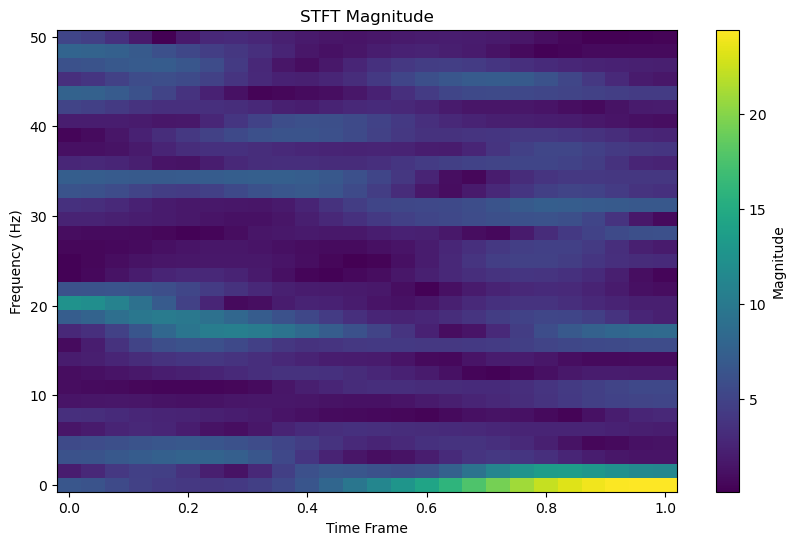

In [30]:
import matplotlib.pyplot as plt
os.environ['KMP_DUPLICATE_LIB_OK']='TRUE'

# 获取一个样本（例如 batch 0, channel 0）
sample_signal = signal[30, 24]
sample_signal = sample_signal.to('cpu')  # 确保在 CPU 上操作

# 检查信号是否异常
assert not torch.isnan(sample_signal).any(), "Signal contains NaN values!"
assert not torch.isinf(sample_signal).any(), "Signal contains Inf values!"

# STFT 参数
window_size = 64
hop_size = 4
sampling_rate = 100
window = torch.hann_window(window_size)

# 计算 STFT
stft_result = torch.stft(
    sample_signal,
    n_fft=window_size,
    hop_length=hop_size,
    win_length=window_size,
    window=window,
    return_complex=True
)

# 提取幅度谱
magnitude = stft_result.abs()
magnitude_positive_freq = magnitude[:window_size // 2 + 1, :].cpu()

# 创建频率和时间轴
freqs = np.fft.fftfreq(window_size, d=1.0 / sampling_rate)[:window_size // 2 + 1]
freqs = np.abs(freqs)
times = np.arange(magnitude_positive_freq.shape[-1]) * (hop_size / sampling_rate)

# 绘制时频图
plt.figure(figsize=(10, 6))
plt.pcolormesh(times, freqs, magnitude_positive_freq.numpy(), shading='auto')
plt.colorbar(label='Magnitude')
plt.xlabel('Time Frame')
plt.ylabel('Frequency (Hz)')
plt.title('STFT Magnitude')
plt.show()

In [52]:
file_name = 'preprocessed_eeg_training.npy'
n_classes = 1654
samples_per_class = 10
repeat_times = 4
                
file_path = os.path.join(data_path, 'sub-08', file_name)
data = np.load(file_path, allow_pickle=True)
                    
preprocessed_eeg_data = torch.from_numpy(data['preprocessed_eeg_data']).float().detach()
times = torch.from_numpy(data['times']).detach()
times

tensor([-0.2000, -0.1900, -0.1800, -0.1700, -0.1600, -0.1500, -0.1400, -0.1300,
        -0.1200, -0.1100, -0.1000, -0.0900, -0.0800, -0.0700, -0.0600, -0.0500,
        -0.0400, -0.0300, -0.0200, -0.0100,  0.0000,  0.0100,  0.0200,  0.0300,
         0.0400,  0.0500,  0.0600,  0.0700,  0.0800,  0.0900,  0.1000,  0.1100,
         0.1200,  0.1300,  0.1400,  0.1500,  0.1600,  0.1700,  0.1800,  0.1900,
         0.2000,  0.2100,  0.2200,  0.2300,  0.2400,  0.2500,  0.2600,  0.2700,
         0.2800,  0.2900,  0.3000,  0.3100,  0.3200,  0.3300,  0.3400,  0.3500,
         0.3600,  0.3700,  0.3800,  0.3900,  0.4000,  0.4100,  0.4200,  0.4300,
         0.4400,  0.4500,  0.4600,  0.4700,  0.4800,  0.4900,  0.5000,  0.5100,
         0.5200,  0.5300,  0.5400,  0.5500,  0.5600,  0.5700,  0.5800,  0.5900,
         0.6000,  0.6100,  0.6200,  0.6300,  0.6400,  0.6500,  0.6600,  0.6700,
         0.6800,  0.6900,  0.7000,  0.7100,  0.7200,  0.7300,  0.7400,  0.7500,
         0.7600,  0.7700,  0.7800,  0.79

In [56]:
import clip
from torch.nn import functional as F

img_directory_training = config["img_directory_training"]
img_directory_test = config["img_directory_test"]

directory = img_directory_training
dirnames = [d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))]
dirnames.sort()

texts = []

# load text data
for dir in dirnames:
    try:
        idx = dir.index('_')
        text_description = dir[idx + 1:]
    except ValueError:
        print(f"Skipped: {dir} due to no '_' found.")
        continue
                    
    new_text_description = f"This picture is {text_description}"
    texts.append(new_text_description)

print(len(texts))

1654


In [57]:
import os
import open_clip
proxy = 'http://127.0.0.1:7897'
os.environ['http_proxy'] = proxy
os.environ['https_proxy'] = proxy
cuda_device_count = torch.cuda.device_count()
print(cuda_device_count)
device = "cuda:0" if torch.cuda.is_available() else "cpu"
# vlmodel, preprocess = clip.load("ViT-B/32", device=device)
model_type = 'ViT-H-14'
vlmodel, preprocess_train, feature_extractor = open_clip.create_model_and_transforms(
    model_type, pretrained='laion2b_s32b_b79k', precision='fp32', device = device)

0


In [58]:
text_inputs = torch.cat([clip.tokenize(t) for t in texts]).to(device)
# print("text_inputs", text_inputs)
            
with torch.no_grad():    
    text_features = vlmodel.encode_text(text_inputs)       
    text_features = F.normalize(text_features, dim=-1).detach()
       
print(text_features.shape)

torch.Size([1654, 1024])


In [61]:
images = []
for folder in dirnames:
    floder_path = os.path.join(directory, folder)
    all_images = [img for img in os.listdir(floder_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
    all_images.sort()
    images.extend(os.path.join(floder_path, img) for img in all_images)

print(len(images))
images[1],images[10]

16540


('D:/reproduction/BCI/EEG_Decoder/data/THINGS/images_set/training_images\\00001_aardvark\\aardvark_02s.jpg',
 'D:/reproduction/BCI/EEG_Decoder/data/THINGS/images_set/training_images\\00002_abacus\\abacus_01b.jpg')

In [62]:
images = []
for folder in dirnames:
    floder_path = os.path.join(dirnames, folder)
    all_images = [img for img in os.listdir(floder_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
    all_images.sort()
    images.extend(os.path.join(floder_path, img) for img in all_images)

print(len(images))
images[1],images[10]

TypeError: expected str, bytes or os.PathLike object, not list

In [64]:
x = torch.tensor([[1.0, 2.0, 2.0], [3.0, 4.0, 0.0]])
y = x
y /= y.norm(dim=-1, keepdim=True)
y

tensor([[0.3333, 0.6667, 0.6667],
        [0.6000, 0.8000, 0.0000]])

In [65]:
z = F.normalize(x, dim=-1).detach()
z

tensor([[0.3333, 0.6667, 0.6667],
        [0.6000, 0.8000, 0.0000]])

In [68]:
proxy = 'http://127.0.0.1:7897'
os.environ['http_proxy'] = proxy
os.environ['https_proxy'] = proxy
from diffusers import AutoencoderKL
vae = AutoencoderKL.from_pretrained("runwayml/stable-diffusion-v1-5/", subfolder="vae")
vae.requires_grad_(False)

ImportError: cannot import name 'cached_download' from 'huggingface_hub' (D:\Program\anaconda3\envs\BCI\lib\site-packages\huggingface_hub\__init__.py)

In [4]:
import torch
a = torch.tensor([[[[1.0, 2.0, 2.0], 
                   [3.0, 4.0, 0.0],
                   [5.0, 7.0, 8.0],
                   [6.0, 3.0, 2.0]],
                  [[4.0, 2.0, 5.0], 
                   [6.0, 4.0, 1.0],
                   [5.0, 7.0, 4.0],
                   [3.0, 1.0, 2.0]],
                  [[6.0, 2.0, 6.0], 
                   [7.0, 5.0, 2.0],
                   [1.0, 7.0, 4.0],
                   [2.0, 3.0, 2.0]]],
                  [[[1.0, 2.0, 2.0], 
                   [5.0, 4.0, 0.0],
                   [9.0, 7.0, 8.0],
                   [6.0, 3.0, 2.0]],
                  [[4.0, 2.0, 5.0], 
                   [6.0, 8.0, 1.0],
                   [5.0, 3.0, 4.0],
                   [3.0, 1.0, 2.0]],
                  [[6.0, 4.0, 6.0], 
                   [7.0, 3.0, 2.0],
                   [1.0, 6.0, 4.0],
                   [2.0, 6.0, 2.0]]]])
print(a.shape)

torch.Size([2, 3, 4, 3])


In [6]:
B = a.view(-1, *a[0].shape[-2:])
print(B.shape)
B

torch.Size([6, 4, 3])


tensor([[[1., 2., 2.],
         [3., 4., 0.],
         [5., 7., 8.],
         [6., 3., 2.]],

        [[4., 2., 5.],
         [6., 4., 1.],
         [5., 7., 4.],
         [3., 1., 2.]],

        [[6., 2., 6.],
         [7., 5., 2.],
         [1., 7., 4.],
         [2., 3., 2.]],

        [[1., 2., 2.],
         [5., 4., 0.],
         [9., 7., 8.],
         [6., 3., 2.]],

        [[4., 2., 5.],
         [6., 8., 1.],
         [5., 3., 4.],
         [3., 1., 2.]],

        [[6., 4., 6.],
         [7., 3., 2.],
         [1., 6., 4.],
         [2., 6., 2.]]])

In [3]:
a = torch.FloatTensor([[1.0, 2.0], [3.0, 4.0]])

In [2]:
import torch
print(torch.__version__)

2.5.0+cu124
